Title: BC_parallel.ipynb

Purpose: Debias CMIP6 Data with ERA5 data with the ISIMIP Method (Lange 2019) from the ibicus package (Spuler et al. 2024)

Furter Information on ibicus: 

https://ibicus.readthedocs.io/en/latest/getting_started/overview.html

Spuler, F. R., Wessel, J. B., Comyn-Platt, E., Varndell, J., and Cagnazzo, C.: ibicus: a new open-source Python package and comprehensive interface for statistical bias adjustment and evaluation in climate modelling (v1.0.1), Geosci. Model Dev., 17, 1249–1269, https://doi.org/10.5194/gmd-17-1249-2024, 2024.

Author: Onno Nennecke on 13.06.2025 Modified: 16.06.2025

Input data: 

    - ERA5 and CMIP6 Data from /climca 
    - Capacity data to create a mask

Output data:

    - Debiased CMIP6 Data

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import cftime
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import time
import re
from ibicus.debias import QuantileMapping
from ibicus.debias import ISIMIP
import multiprocessing


# Importing functions
import Functions.grid_func as grid_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load ERA5 Data

In [ ]:
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'

# Select all files in the range 2015-2024
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files

# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# SSRD_list = files_by_variable['SSRD']
# SSRD_list

# Read datasets for each variable
datasets_by_variable = {}
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    
    if var == 'SSRD':
        ds = ds / 3600 # Convert from J/m2 to W/m2
    ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds_daily
    if var == 'tas':
        tasmax = ds.resample(time='1D').max()
        tasmax = tasmax.rename({'var167': 'tasmax'})
        datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds, s = 47, n = 56, w = 6, e = 16) # One ° less in the north to prevent NaN values
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
ERA5_ds = xr.merge(ds_list)

# Assign coordinates for ESM
ERA5_ds = ERA5_ds.assign_coords(ESM='ERA5')

# Remove every 29.02
ERA5_ds = ERA5_ds.where(~((ERA5_ds['time.month'] == 2) & (ERA5_ds['time.day'] == 29)), drop=True)

ERA5_ds['sfcWind'] = np.sqrt(ERA5_ds['U100']**2 + ERA5_ds['V100']**2)
# ERA5_ds['tas'] = ERA5_ds['tas'] - 273.15
# ERA5_ds['tasmax'] = ERA5_ds['tasmax'] - 273.15

ERA5_ds

ERA5_ssrd =  ERA5_ds['rsds']
# ERA5_ssrd
ERA5_sfcWind = ERA5_ds['sfcWind']
# ERA5_sfcWind
ERA5_tas = ERA5_ds['tas'] 
# ERA5_tas
ERA5_tasmax = ERA5_ds['tasmax']
# ERA5_tasmax

ERA5_time = ERA5_ds['time']

In [7]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

filtered_files

ds = xr.open_mfdataset(filtered_files, combine='by_coords', preprocess=grid_func.preprocess_ERA5_psl)

# Regrid the dataset
regridded_ds = grid_func.regrid(ds, s = 30, n = 70, w = 340, e = 30)


# Assign coordinates for ESM
regridded_ds = regridded_ds.assign_coords(ESM='ERA5')
# Rename the variable to 'pls'
ERA5_ds_psl = regridded_ds.rename({'var151': 'psl'})

ERA5_ds_psl = ERA5_ds_psl.where(~((ERA5_ds_psl['time.month'] == 2) & (ERA5_ds_psl['time.day'] == 29)), drop=True)

ERA5_ds_psl = ERA5_ds_psl.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned

### Define used models

In [41]:
# Read the dataframe from the csv file
df = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')

# Change the ref column to 1 for the first instance of each model
df['Ref'] = df.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)
df

,ESM,Institution,run,Ref
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0
3,BCC-CSM2-MR,BCC,r1i1p1f1,1
4,CESM2,NCAR,r4i1p1f1,1
...,...,...,...,...
94,UKESM1-0-LL,MOHC,r3i1p1f2,0
95,UKESM1-0-LL,MOHC,r8i1p1f2,0
96,UKESM1-0-LL,NIMS-KMA,r15i1p1f2,1
97,UKESM1-0-LL,NIMS-KMA,r13i1p1f2,0


In [ ]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP

# Institution = df['Institution']
# # Institution = ['CSIRO-ARCCSS', 'BCC', 'NCAR', 'EC-Earth-Consortium', 'NOAA-GFDL', 'NIMS-KMA', 'DKRZ', 'MRI', 'AS-RCEC', 'MOHC', 'NIMS-KMA']
# # Institution = ['CSIRO-ARCCSS']

# ESMs = df['ESM']
# # ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']
# # ESMs = ['ACCESS-CM2']

# run = df['run']
# # run = 'r1i1p1f1'

scenario = 'ssp370'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
# variables = ['sfcWind', 'rsds', 'tas', 'tasmax', 'psl'] # List of variables

grid_def = '*'
version = '*'

In [35]:
ESM = 'UKESM1-0-LL'
run = 'r15i1p1f2'
var = 'tas' # Variable to debias

output_file = f'/climca/people/onennecke/debiased_data/{ESM}_{run}_{var}_debiased.nc'
if os.path.isfile( output_file ) == False:
    print('Doenst exist, starting debiasing...')
else:
    print('File already exists, skipping debiasing...')

Doenst exist, starting debiasing...


### Debiasing

In [ ]:
# for i in range(len(df[0:2])):
def one_run(i):
    run_time = time.time()
    ESM = df['ESM'][i]
    Inst = df['Institution'][i]
    run = df['run'][i]
    print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
    
    
    for var in variables:
        output_file = f'/climca/people/onennecke/debiased_data/{ESM}_{run}_{var}_debiased.nc'
        if os.path.isfile( output_file ) == False:
            
            print(f'Processing variable: {var}')
            path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{run}_*'
            files = [f for f in glob.glob(path) if f.endswith('.nc')]

            nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            nc = nc[[var]]
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025))) # Filter years
            nc = grid_func.regrid(nc, s = 47, n = 56, w = 6, e = 16)  # Regrid the data
            
            nc = nc.drop_vars('height') if 'height' in nc.coords else nc
            
            if isinstance(nc.time.values[0], cftime.Datetime360Day):
                print('Using 360-day calendar')
                # Duplicate the 30th of the month for these months
                extra_months = [4, 5, 6, 7, 8]

                # Duplicate the dataset for these time points
                duplicates = []
                for m in extra_months:
                    mask = (nc['time.month'] == m) & (nc['time.day'] == 30)
                    ds_dup = nc.sel(time=nc.time[mask])
                    duplicates.append(ds_dup)

                # Put everything together and sort by time
                nc = xr.concat([nc] + duplicates, dim='time').sortby('time')

                nc = nc.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
            elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
                print('Using no-leap calendar')
                nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            else:
                print('Using standard calendar')
                nc = nc.where(~((nc['time.month'] == 2) & (nc['time.day'] == 29)), drop=True)
                nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            
            
            ref_run = str(df.loc[(df.ESM == ESM)&(df.Institution == Inst)&(df.Ref == 1), 'run'].values[0])
            path_ref = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{ref_run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{ref_run}_*'
            ref_files = [f for f in glob.glob(path_ref) if f.endswith('.nc')]

            nc_ref = xr.open_mfdataset(ref_files, preprocess=grid_func.preprocess)
            nc_ref = nc_ref[[var]]
            nc_ref = nc_ref.sel(time=nc_ref.time.dt.year.isin(range(2015, 2025))) # Filter years
            nc_ref = grid_func.regrid(nc_ref, s = 47, n = 56, w = 6, e = 16)  # Regrid the data
            
            nc_ref = nc_ref.drop_vars('height') if 'height' in nc_ref.coords else nc_ref
            
            if isinstance(nc_ref.time.values[0], cftime.Datetime360Day):
                print('Using 360-day calendar')
                # Duplicate the 30th of the month for these months
                extra_months = [4, 5, 6, 7, 8]

                # Duplicate the dataset for these time points
                duplicates = []
                for m in extra_months:
                    mask = (nc_ref['time.month'] == m) & (nc_ref['time.day'] == 30)
                    ds_dup = nc_ref.sel(time=nc_ref.time[mask])
                    duplicates.append(ds_dup)

                # Put everything together and sort by time
                nc_ref = xr.concat([nc_ref] + duplicates, dim='time').sortby('time')

                nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
            elif isinstance(nc_ref.time.values[0], cftime.DatetimeNoLeap):
                print('Using no-leap calendar')
                nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            else:
                print('Using standard calendar')
                nc_ref = nc_ref.where(~((nc_ref['time.month'] == 2) & (nc_ref['time.day'] == 29)), drop=True)
                nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
            
            # Old code
            # if df['Ref'][i] == 1:
            #     if i == 0 and var == variables[0]:
            #         # Use the first dataset as reference
            #         reference_ds = nc.copy()
            #     reference_ds[var] = nc[var].copy()  # Update reference dataset with the current variable

            obs_era5 = ERA5_ds[var].values
            cm_hist = nc_ref[var].values
            cm_future = nc[var].values
            
            if not (cm_hist.shape == obs_era5.shape == cm_future.shape): # Check if the shapes match
                print(f"Shape mismatch: cm_hist {cm_hist.shape}, obs_era5 {obs_era5.shape}, cm_future {cm_future.shape}")

            if np.isnan(cm_hist).any() or np.isnan(cm_future).any() or np.isnan(obs_era5).any(): # Check if there are any NaN values in the arrays
                print(f"NaN values found in the arrays for {var} in {ESM}, {run}")


            if var == 'tasmax':
                debiaser = QuantileMapping.from_variable(var)
                debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future)

            else:
                # debiaser = QuantileMapping.from_variable(var)
                # debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future)
                debiaser = ISIMIP.from_variable(var)
                debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future, time_obs = nc.time.values, time_cm_hist = nc.time.values, time_cm_future = nc.time.values)
                
            nc[var] = (('time', 'lat', 'lon'), debiased_cm_future_era5)
            
            plt.figure(figsize=(6, 4))
            sns.boxplot(data=[cm_hist.flatten(), debiased_cm_future_era5.flatten(), obs_era5.flatten()],
                        palette=["lightblue", "lightgreen", "lightcoral"],
                        showfliers=False)
            plt.xticks([0, 1, 2], ['CMIP6 Historical', 'CMIP6 Debiased Future', 'ERA5 Observations'])
            plt.ylabel(f'{var} Values')
            plt.title(f'Comparison of {var} Distributions for {ESM} {run} from {Inst}')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            # Save plot
            plot_file = f'/home/onennecke/Code/Bias_analysis/bc_plots/{ESM}_{run}_{var}_debiased_plot.png'
            plt.savefig(plot_file, dpi=300)
            plt.close()  # Close the plot to free memory


            # Save the debiased dataset
            nc.to_netcdf(output_file)
            

            print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s', '\n')
            # return nc
            # break
    var = 'psl'

    output_file = f'/climca/people/onennecke/debiased_data/{ESM}_{run}_{var}_debiased.nc'
    if os.path.isfile( output_file ) == False:

        run_time = time.time()

        print(f'Processing variable: {var}')
        path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{run}_*'
        files = [f for f in glob.glob(path) if f.endswith('.nc')]


        nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess_psl)
        nc = nc[[var]]
        nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025))) # Filter years
        nc = grid_func.regrid(nc, s = 30, n = 70, w = 340, e = 30)
        obs_era5 = ERA5_ds_psl[var].values

        nc = nc.drop_vars('height') if 'height' in nc.coords else nc

        if isinstance(nc.time.values[0], cftime.Datetime360Day):
            print('Using 360-day calendar')
            # Duplicate the 30th of the month for these months
            extra_months = [4, 5, 6, 7, 8]

            # Duplicate the dataset for these time points
            duplicates = []
            for m in extra_months:
                mask = (nc['time.month'] == m) & (nc['time.day'] == 30)
                ds_dup = nc.sel(time=nc.time[mask])
                duplicates.append(ds_dup)

            # Put everything together and sort by time
            nc = xr.concat([nc] + duplicates, dim='time').sortby('time')

            nc = nc.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
        elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
            print('Using no-leap calendar')
            nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
        else:
            print('Using standard calendar')
            nc = nc.where(~((nc['time.month'] == 2) & (nc['time.day'] == 29)), drop=True)
            nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned


        ref_run = str(df.loc[(df.ESM == ESM)&(df.Institution == Inst)&(df.Ref == 1), 'run'].values[0])
        path_ref = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{ref_run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{ref_run}_*'
        ref_files = [f for f in glob.glob(path_ref) if f.endswith('.nc')]

        nc_ref = xr.open_mfdataset(ref_files, preprocess=grid_func.preprocess_psl)
        nc_ref = nc_ref[[var]]
        nc_ref = nc_ref.sel(time=nc_ref.time.dt.year.isin(range(2015, 2025))) # Filter years
        nc_ref = grid_func.regrid(nc_ref, s = 30, n = 70, w = 340, e = 30)  # Regrid the data

        nc_ref = nc_ref.drop_vars('height') if 'height' in nc_ref.coords else nc_ref

        if isinstance(nc_ref.time.values[0], cftime.Datetime360Day):
            print('Using 360-day calendar')
            # Duplicate the 30th of the month for these months
            extra_months = [4, 5, 6, 7, 8]

            # Duplicate the dataset for these time points
            duplicates = []
            for m in extra_months:
                mask = (nc_ref['time.month'] == m) & (nc_ref['time.day'] == 30)
                ds_dup = nc_ref.sel(time=nc_ref.time[mask])
                duplicates.append(ds_dup)

            # Put everything together and sort by time
            nc_ref = xr.concat([nc_ref] + duplicates, dim='time').sortby('time')

            nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
        elif isinstance(nc_ref.time.values[0], cftime.DatetimeNoLeap):
            print('Using no-leap calendar')
            nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
        else:
            print('Using standard calendar')
            nc_ref = nc_ref.where(~((nc_ref['time.month'] == 2) & (nc_ref['time.day'] == 29)), drop=True)
            nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned



        # if df['Ref'][i] == 1:
        #     if i == 0:
        #         # Use the first dataset as reference
        #         reference_ds = nc.copy()
        #     reference_ds[var] = nc[var].copy()  # Update reference dataset with the current variable

        
        cm_hist = nc_ref[var].values
        cm_future = nc[var].values

        if not (cm_hist.shape == obs_era5.shape == cm_future.shape): # Check if the shapes match
            print(f"Shape mismatch: cm_hist {cm_hist.shape}, obs_era5 {obs_era5.shape}, cm_future {cm_future.shape}")

        if np.isnan(cm_hist).any() or np.isnan(cm_future).any() or np.isnan(obs_era5).any(): # Check if there are any NaN values in the arrays
            print(f"NaN values found in the arrays for {var} in {ESM}, {run}")

        # debiaser = QuantileMapping.from_variable(var)
        # debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future)
        debiaser = ISIMIP.from_variable(var)
        debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future, time_obs = nc.time.values, time_cm_hist = nc.time.values, time_cm_future = nc.time.values)

        nc[var] = (('time', 'lat', 'lon'), debiased_cm_future_era5)
            
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=[cm_hist.flatten(), debiased_cm_future_era5.flatten(), obs_era5.flatten()],
            palette=["lightblue", "lightgreen", "lightcoral"],
            showfliers=False)
        plt.xticks([0, 1, 2], ['CMIP6 Historical', 'CMIP6 Debiased Future', 'ERA5 Observations'])
        plt.ylabel(f'{var} Values')
        plt.title(f'Comparison of {var} Distributions for {ESM} {run} from {Inst}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        # Save plot
        plot_file = f'/home/onennecke/Code/Bias_analysis/bc_plots/{ESM}_{run}_{var}_debiased_plot.png'
        plt.savefig(plot_file, dpi=300)
        plt.close()  # Close the plot to free memory

        # Save the debiased dataset
        nc.to_netcdf(output_file)

        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')



In [24]:
p = multiprocessing.Pool(2)
result = p.map(one_run, range(len(df[0:2])))
result

Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 
Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 


Processing variable: sfcWind
Processing variable: sfcWind


Process ForkPoolWorker-20:
Process ForkPoolWorker-19:
Traceback (most recent call last):
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
                    ^^^^^^^^^^^^^^^^^^^
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/multiprocessing/pool.py", line 125, in worker
    result = (Tru

KeyboardInterrupt: 

  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/array/core.py", line 1743, in __array__
    x = self.compute()
        ^^^^^^^^^^^^^^
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/base.py", line 374, in compute
    (result,) = compute(self, traverse=False, **kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/base.py", line 662, in compute
    results = schedule(dsk, keys, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/queue.py", line 171, in get
    self.not_empty.wait()
  File "/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/threading.py", line 355, in wait
    waiter.acquire()
KeyboardInterrupt


In [ ]:
var = 'psl'

output_file = f'/climca/people/onennecke/debiased_data/{ESM}_{run}_{var}_debiased.nc'
if os.path.isfile( output_file ) == False:

    run_time = time.time()

    print(f'Processing variable: {var}')
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{run}_*'
    files = [f for f in glob.glob(path) if f.endswith('.nc')]


    nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess_psl)
    nc = nc[[var]]
    nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025))) # Filter years
    nc = grid_func.regrid(nc, s = 30, n = 70, w = 340, e = 30)
    obs_era5 = ERA5_ds_psl[var].values

    nc = nc.drop_vars('height') if 'height' in nc.coords else nc

    if isinstance(nc.time.values[0], cftime.Datetime360Day):
        print('Using 360-day calendar')
        # Duplicate the 30th of the month for these months
        extra_months = [4, 5, 6, 7, 8]

        # Duplicate the dataset for these time points
        duplicates = []
        for m in extra_months:
            mask = (nc['time.month'] == m) & (nc['time.day'] == 30)
            ds_dup = nc.sel(time=nc.time[mask])
            duplicates.append(ds_dup)

        # Put everything together and sort by time
        nc = xr.concat([nc] + duplicates, dim='time').sortby('time')

        nc = nc.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
    elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
        print('Using no-leap calendar')
        nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
    else:
        print('Using standard calendar')
        nc = nc.where(~((nc['time.month'] == 2) & (nc['time.day'] == 29)), drop=True)
        nc = nc.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned


    ref_run = str(df.loc[(df.ESM == ESM)&(df.Ref == 1), 'run'].values[0])
    path_ref = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{ref_run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{ref_run}_*'
    ref_files = [f for f in glob.glob(path_ref) if f.endswith('.nc')]

    nc_ref = xr.open_mfdataset(ref_files, preprocess=grid_func.preprocess)
    nc_ref = nc_ref[[var]]
    nc_ref = nc_ref.sel(time=nc_ref.time.dt.year.isin(range(2015, 2025))) # Filter years
    nc_ref = grid_func.regrid(nc_ref, s = 47, n = 56, w = 6, e = 16)  # Regrid the data

    nc_ref = nc_ref.drop_vars('height') if 'height' in nc_ref.coords else nc_ref

    if isinstance(nc_ref.time.values[0], cftime.Datetime360Day):
        print('Using 360-day calendar')
        # Duplicate the 30th of the month for these months
        extra_months = [4, 5, 6, 7, 8]

        # Duplicate the dataset for these time points
        duplicates = []
        for m in extra_months:
            mask = (nc_ref['time.month'] == m) & (nc_ref['time.day'] == 30)
            ds_dup = nc_ref.sel(time=nc_ref.time[mask])
            duplicates.append(ds_dup)

        # Put everything together and sort by time
        nc_ref = xr.concat([nc_ref] + duplicates, dim='time').sortby('time')

        nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Replace time coordinates with ERA5 time
    elif isinstance(nc_ref.time.values[0], cftime.DatetimeNoLeap):
        print('Using no-leap calendar')
        nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned
    else:
        print('Using standard calendar')
        nc_ref = nc_ref.where(~((nc_ref['time.month'] == 2) & (nc_ref['time.day'] == 29)), drop=True)
        nc_ref = nc_ref.assign_coords(time=ERA5_time)  # Ensure time coordinates are aligned



    # if df['Ref'][i] == 1:
    #     if i == 0:
    #         # Use the first dataset as reference
    #         reference_ds = nc.copy()
    #     reference_ds[var] = nc[var].copy()  # Update reference dataset with the current variable

    
    cm_hist = nc_ref[var].values
    cm_future = nc[var].values

    if not (cm_hist.shape == obs_era5.shape == cm_future.shape): # Check if the shapes match
        print(f"Shape mismatch: cm_hist {cm_hist.shape}, obs_era5 {obs_era5.shape}, cm_future {cm_future.shape}")

    if np.isnan(cm_hist).any() or np.isnan(cm_future).any() or np.isnan(obs_era5).any(): # Check if there are any NaN values in the arrays
        print(f"NaN values found in the arrays for {var} in {ESM}, {run}")

    # debiaser = QuantileMapping.from_variable(var)
    # debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future)
    debiaser = ISIMIP.from_variable(var)
    debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future, time_obs = nc.time.values, time_cm_hist = nc.time.values, time_cm_future = nc.time.values)

    nc[var] = (('time', 'lat', 'lon'), debiased_cm_future_era5)
        
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=[cm_hist.flatten(), debiased_cm_future_era5.flatten(), obs_era5.flatten()],
        palette=["lightblue", "lightgreen", "lightcoral"],
        showfliers=False)
    plt.xticks([0, 1, 2], ['CMIP6 Historical', 'CMIP6 Debiased Future', 'ERA5 Observations'])
    plt.ylabel(f'{var} Values')
    plt.title(f'Comparison of {var} Distributions for {ESM} {run} from {Inst}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # Save plot
    plot_file = f'/home/onennecke/Code/Bias_analysis/bc_plots/{ESM}_{run}_{var}_debiased_plot.png'
    plt.savefig(plot_file, dpi=300)
    plt.close()  # Close the plot to free memory

    # Save the debiased dataset
    nc.to_netcdf(output_file)

    print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')


In [ ]:
var = 'psl'
for i in range(len(df)):
    run_time = time.time()
    ESM = df['ESM'][i]
    Inst = df['Institution'][i]
    run = df['run'][i]
    print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}')
    
    
    print(f'Processing variable: {var}')
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{var}/{grid_def}/{version}/{var}_{time_res}_{ESM}_{scenario}_{run}_*'
    files = [f for f in glob.glob(path) if f.endswith('.nc')]
    

    nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess_psl)
    nc = nc[[var]]
    nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025))) # Filter years
    nc = grid_func.regrid(nc, s = 30, n = 70, w = 340, e = 30)
    obs_era5 = ERA5_ds_psl[var].values
    
    nc = nc.drop_vars('height') if 'height' in nc.coords else nc
    
    if df['Ref'][i] == 1:
        if i == 0:
            # Use the first dataset as reference
            reference_ds = nc.copy()
        reference_ds[var] = nc[var].copy()  # Update reference dataset with the current variable

    
    cm_hist = reference_ds[var].values
    cm_future = nc[var].values

    if not (cm_hist.shape == obs_era5.shape == cm_future.shape): # Check if the shapes match
        print(f"Shape mismatch: cm_hist {cm_hist.shape}, obs_era5 {obs_era5.shape}, cm_future {cm_future.shape}")

    if np.isnan(cm_hist).any() or np.isnan(cm_future).any() or np.isnan(obs_era5).any(): # Check if there are any NaN values in the arrays
        print(f"NaN values found in the arrays for {var} in {ESM}, {run}")

    # debiaser = QuantileMapping.from_variable(var)
    # debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future)
    debiaser = ISIMIP.from_variable(var)
    debiased_cm_future_era5 = debiaser.apply(obs_era5, cm_hist, cm_future, time_obs = nc.time.values, time_cm_hist = nc.time.values, time_cm_future = nc.time.values)

    nc[var] = (('time', 'lat', 'lon'), debiased_cm_future_era5)
    
    # plt.figure(figsize=(6, 4))
    # sns.boxplot(data=[cm_hist.flatten(), debiased_cm_future_era5.flatten(), obs_era5.flatten()],
    #     palette=["lightblue", "lightgreen", "lightcoral"],
    #     showfliers=False)
    # plt.xticks([0, 1, 2], ['CMIP6 Historical', 'CMIP6 Debiased Future', 'ERA5 Observations'])
    # plt.ylabel(f'{var} Values')
    # plt.title(f'Comparison of {var} Distributions for {ESM} {run} from {Inst}')
    # plt.grid(axis='y', linestyle='--', alpha=0.7)
    # plt.tight_layout()
    # plt.show()

    # Save the debiased dataset
    # nc.to_netcdf(f'/climca/people/onennecke/debiased_data/{ESM}_{run}_{var}_debiased.nc')

    print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
    break


Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1
Processing variable: sfcWind


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/ibicus/debias/_quantile_mapping.py:198: UserWarning: The default settings for variable sfcWind in debiaser QuantileMapping are currently still experimental and may not have been evaluated in the peer-reviewed literature. Please review the results with care!
  return super()._from_variable(


Shape cm_hist: (3653, 9, 10)
Shape cm_future: (3653, 9, 10)
Shape obs_era5: (3653, 9, 10)
NaN in cm_hist: False
NaN in cm_future: False
NaN in obs_era5: False


100%|██████████| 90/90 [00:04<00:00, 18.76it/s]
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains values outside the reasonable physical range of [1e-05, 500] for the variable: Daily mean near-surface wind speed. This might be due to values outside the range in the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully.
  self._check_output(output)


Run time:  1 m 18.1 s
Processing variable: tas
Shape cm_hist: (3653, 9, 10)
Shape cm_future: (3653, 9, 10)
Shape obs_era5: (3653, 9, 10)
NaN in cm_hist: False
NaN in cm_future: False
NaN in obs_era5: False


...

Shape cm_hist: (3653, 9, 10)
Shape cm_future: (3653, 9, 10)
Shape obs_era5: (3653, 9, 10)
NaN in cm_hist: False
NaN in cm_future: False
NaN in obs_era5: False


100%|██████████| 90/90 [00:14<00:00,  6.30it/s]


Run time:  2 m 47.0 s
Processing variable: psl
Shape cm_hist: (3653, 9, 10)
Shape cm_future: (3653, 40, 50)
Shape obs_era5: (3653, 40, 50)
NaN in cm_hist: False
NaN in cm_future: False
NaN in obs_era5: False


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/ibicus/debias/_quantile_mapping.py:198: UserWarning: The default settings for variable psl in debiaser QuantileMapping are currently still experimental and may not have been evaluated in the peer-reviewed literature. Please review the results with care!
  return super()._from_variable(


ValueError: obs, cm_hist, cm_future need to have same (number of) spatial dimensions. The arrays of obs, cm_hist and cm_future are assumed to have the following structure: [t, x, y] where t is the time dimension and x, y are spatial ones.

---

#### Read finished data in

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [44]:


path = '/climca/people/onennecke/debiased_data/*'
files = [f for f in sorted(glob.glob(path)) if f.endswith('.nc')]

print(files[1])
nc = xr.open_mfdataset(files[1])
nc

/climca/people/onennecke/debiased_data/ACCESS-CM2_r1i1p1f1_sfcWind_debiased.nc


<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3653, lat: 9, lon: 10)
Coordinates:
  * time      (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-31T1...
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    sfcWind   (time, lat, lon) float32 1MB dask.array<chunksize=(3653, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

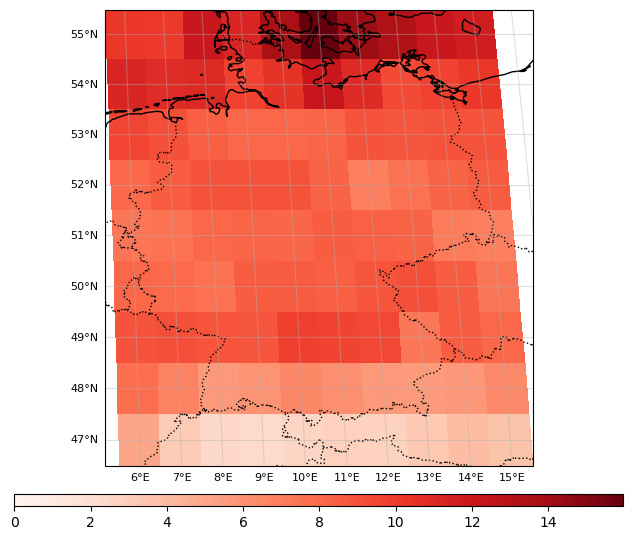

In [47]:
lon_edges = nc['lon'].values
lat_edges = nc['lat'].values

vmin = 0 
vmax = 1

# Plot the data
timestep = 0

fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = nc['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('')

plt.tight_layout()
plt.show()